<a href="https://colab.research.google.com/github/diazalvarez1010-ship-it/Lenguajes-de-programacion-25/blob/main/Taller_Portafolio_Estudiantes%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [3]:
!pip install yfinance plotly

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

**Respuesta**:Porque Adj Close ajusta el precio teniendo en cuenta dividendos, splits y otros eventos corporativos, lo que refleja el valor real de la acción para el inversionista.

In [60]:
# COMPLETAR: descarga los precios de las acciones usando yf.download

acciones = ["GOOG", "AMZN", "MSFT"]
datos = yf.download(tickers=acciones, period="3y")
datos.head(5)

/tmp/ipython-input-4099868671.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers=acciones, period="3y")
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AMZN        GOOG        MSFT        AMZN        GOOG   
Date                                                                     
2022-09-19  124.660004  103.144157  238.584900  124.709999  103.313000   
2022-09-20  122.190002  101.137886  236.565109  124.400002  102.468775   
2022-09-21  118.540001   99.330254  233.150070  123.760002  102.786596   
2022-09-22  117.309998   99.886452  235.130783  118.790001  100.988908   
2022-09-23  113.779999   98.495972  232.145081  116.050003   99.429585   

Price                          Low                                Open  \
Ticker            MSFT        AMZN        GOOG        MSFT        AMZN   
Date                                                                     
2022-09-19  239.189846  121.800003  101.674221  235.003982  122.160004   
2022-09-20  237.599378  121.139999  100.432713  233.823318  123.349998   
2022-09-21  241.648663  118.449997   99.310385  233.101281  122.489998   
2022-09-22  237.940883  116.260002   98.734340  231.803564  117.080002   
2022-09-23  235.277172  112.059998   97.343860  229.491101  116.000000   

Price                                 Volume                      
Ticker            GOOG        MSFT      AMZN      GOOG      MSFT  
Date                                                              
2022-09-19  101.843064  236.584655  47279700  19738600  26826900  
2022-09-20  102.180745  236.194343  47698400  24001700  26660300  
2022-09-21  101.545092  238.340947  58498900  26596800  28625600  
2022-09-22   98.774061  232.096270  55229200  21272700  31061200  
2022-09-23   99.379922  233.725754  65126700  25657000  34176000

In [12]:
datos.tail(5) # Veo los últimos 5 datos

Price            Close                                High              \
Ticker            AMZN        GOOG        MSFT        AMZN        GOOG   
Date                                                                     
2025-09-11  229.949997  240.779999  501.010010  231.529999  242.570007   
2025-09-12  228.149994  241.380005  509.899994  230.789993  242.423004   
2025-09-15  231.429993  251.759995  515.359985  233.729996  252.750000   
2025-09-16  234.050003  251.419998  509.040009  235.899994  253.229996   
2025-09-17  231.449997  248.524994  509.660004  234.300003  251.949997   

Price                          Low                                Open  \
Ticker            MSFT        AMZN        GOOG        MSFT        AMZN   
Date                                                                     
2025-09-11  503.170013  229.339996  236.580002  497.880005  231.490005   
2025-09-12  512.549988  226.289993  238.500000  503.850006  230.350006   
2025-09-15  515.469971  230.320007  244.979996  507.000000  230.630005   
2025-09-16  517.229980  232.229996  249.714996  508.600006  232.940002   
2025-09-17  510.820007  229.710007  247.880005  505.940002  233.770004   

Price                                 Volume                      
Ticker            GOOG        MSFT      AMZN      GOOG      MSFT  
Date                                                              
2025-09-11  240.139999  502.250000  37485600  21308600  18881600  
2025-09-12  240.800003  506.649994  38447500  14521900  23624900  
2025-09-15  245.139999  508.790009  33243300  29935200  17143800  
2025-09-16  252.330002  516.880005  38162000  24481700  19688100  
2025-09-17  251.460007  510.640015  19176553  10049468   6117527

## 3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 **Pregunta:** ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

/tmp/ipython-input-1432942008.py:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(datos[i], label=i)


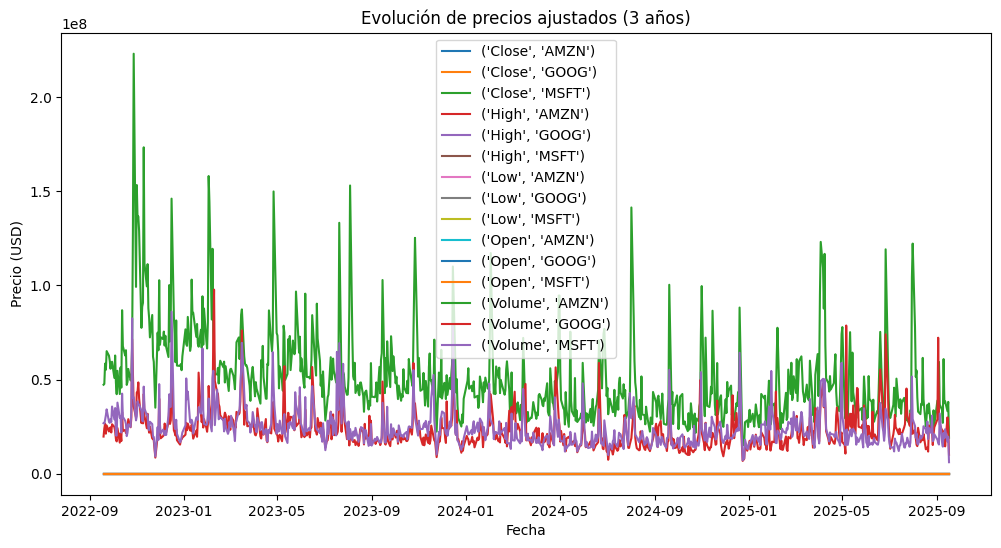

In [36]:
# COMPLETAR: grafica las tres series de precios en una sola gráfica

plt.figure(figsize=(12,6))
for i in datos.columns:
    plt.plot(datos[i], label=i)
plt.title("Evolución de precios ajustados (3 años)")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.show()


In [41]:
import plotly.express as px

## 4. Rentabilidades
Calcula las **rentabilidades logarítmicas diarias** y grafícalas.

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

In [ ]:
# COMPLETAR: calcula los rendimientos logarítmicos

rendimientos = # COMPLETAR AQUÍ
rendimientos.head()

# Graficar
# COMPLETAR AQUÍ

## 5. Medidas estadísticas
Calcula la **rentabilidad promedio** y la **volatilidad (desviación estándar)** de cada acción.

🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

In [ ]:
# COMPLETAR: calcula media y desviación estándar

media = # COMPLETAR AQUÍ
volatilidad = # COMPLETAR AQUÍ

print("Rentabilidad promedio diaria:")
print(media)
print("\nVolatilidad diaria:")
print(volatilidad)

## 6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

🔎 **Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

In [ ]:
# COMPLETAR: calcula la correlación y haz un mapa de calor con seaborn

correlacion = # COMPLETAR AQUÍ
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.show()

## 7. Portafolio simulado
Supón un portafolio con la siguiente distribución:
- 40% Google
- 30% Amazon
- 30% Microsoft

Calcula el **retorno esperado** y la **volatilidad del portafolio**.

🔎 **Preguntas:**
1. ¿Cómo interpretas el retorno esperado del portafolio?
2. ¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

In [ ]:
# COMPLETAR: cálculo del retorno y riesgo del portafolio

pesos = np.array([0.4, 0.3, 0.3])

retorno_portafolio = # COMPLETAR AQUÍ
covarianza = # COMPLETAR AQUÍ
vol_portafolio = # COMPLETAR AQUÍ

print("Retorno esperado del portafolio (diario):", retorno_portafolio)
print("Volatilidad del portafolio (diaria):", vol_portafolio)

## ✍️ 8. Conclusión final
Redacta un análisis completo del portafolio respondiendo:
- ¿Qué acción fue más rentable y cuál más riesgosa?
- ¿Qué tan correlacionadas están las acciones?
- ¿Qué aportó la diversificación al portafolio?
- Si fueras un inversionista, ¿invertirías en este portafolio? Justifica tu respuesta.